In [145]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
import os

from torch.utils.data import Dataset, random_split, DataLoader, dataset

import pathlib
import matplotlib.patches as patches
from data.pets_dataset import OxfordIIITPetDataset, get_class_map

from models import MultiTaskPerceptionModel
from losses import DiceLoss, IoULoss
from PIL import Image

import wandb
# wandb.init(project="Multitask-Pet-Detection")

In [3]:
multitask_model = MultiTaskPerceptionModel(num_breeds      = 37, 
                                           seg_classes     = 3, 
                                           in_channels     = 3, 
                                           classifier_path = "checkpoints/classifier.pth",
                                           localizer_path  = "checkpoints/localizer.pth",
                                           unet_path       = "checkpoints/unet.pth",
                                           train_classifier=True,
                                           train_localizer=True,
                                           train_unet=True)


classifier loaded!
localizer loaded!
unet loaded!


In [ ]:
mappings = get_class_map(pathlib.Path("oxford-iiit-pet"))

dataset = OxfordIIITPetDataset(root_dir = "oxford-iiit-pet")

train_ds, test_ds = random_split(dataset, [int(0.8 * len(dataset)), len(dataset)-int(0.8 * len(dataset))])

train_dl = DataLoader(train_ds, batch_size = 1, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size = 1, shuffle=True)


## 2.4 Inside the Black Box: Feature Maps

In [16]:
sample = next(iter(train_dl))
sample_image = sample["image"]

activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

hooks = []

for name, layer in multitask_model.model_classifier.named_modules():
    if isinstance(layer, torch.nn.Conv2d):
        h = layer.register_forward_hook(get_activation(name))
        hooks.append(h)

_ = multitask_model.model_classifier(sample_image)

for h in hooks:
    h.remove()

activations.keys()

dict_keys(['conv_layers.0', 'conv_layers.4', 'conv_layers.8', 'conv_layers.11', 'conv_layers.15', 'conv_layers.18', 'conv_layers.22', 'conv_layers.25'])

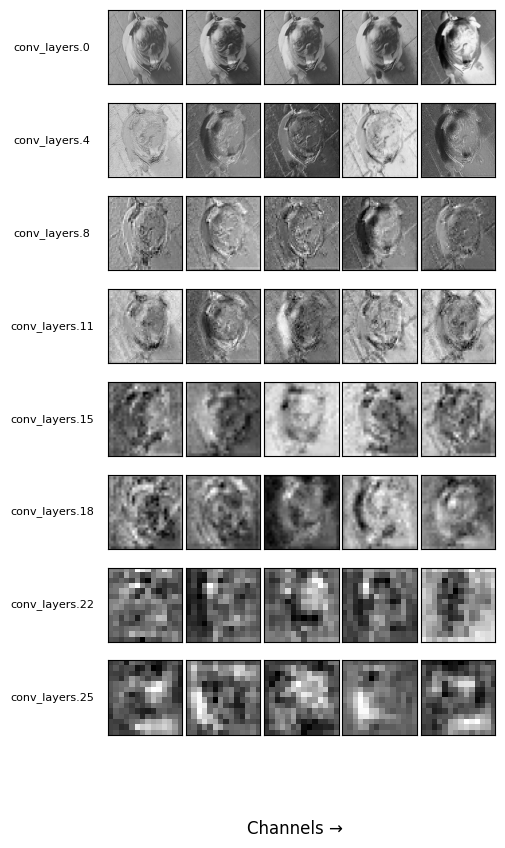

In [17]:
wandb.init(project="Multitask-Pet-Detection")

max_channels = 5
keys = list(activations.keys())

fig, axs = plt.subplots(
    len(keys), 
    max_channels, 
    figsize=(max_channels, 1.2 * len(keys))  
)

for i, key in enumerate(keys):
    act = activations[key][0] 
    C = act.shape[0]
    
    for j in range(max_channels):
        ax = axs[i, j] if len(keys) > 1 else axs[j]
        
        if j < C:
            img = act[j].cpu()
            img = (img - img.min()) / (img.max() - img.min() + 1e-5)
            ax.imshow(img, cmap='gray')
        else:
            ax.axis('off')
        
        ax.set_xticks([])
        ax.set_yticks([])
    
    axs[i, 0].set_ylabel(key, rotation=0, labelpad=40, fontsize=8, va='center')

fig.supxlabel("Channels →", fontsize=12)

plt.subplots_adjust(hspace=0.05, wspace=0.05)

wandb.log({"activation_maps": wandb.Image(fig)})


# plt.show()

## 2.1 The Regularization Effect of Dropout

In [33]:
from models import VGG11Classifier

# model_classifier = VGG11Classifier(in_channels = 3, num_classes = 37, use_batchnorm = False)
# checkpoint = torch.load("/Users/mohamedmafaz/Downloads/2_1_no-batchnorm.pth", map_location=torch.device('cpu'))
# model_classifier.load_state_dict(checkpoint['state_dict'])

sample = next(iter(train_dl))
sample_image = sample["image"]

activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

hooks = []

for name, layer in multitask_model.model_classifier.named_modules():
    if isinstance(layer, torch.nn.Conv2d):
        h = layer.register_forward_hook(get_activation(name))
        hooks.append(h)



_ = multitask_model.model_classifier(sample_image)

for h in hooks:
    h.remove()

activations.keys()

dict_keys(['conv_layers.0', 'conv_layers.4', 'conv_layers.8', 'conv_layers.11', 'conv_layers.15', 'conv_layers.18', 'conv_layers.22', 'conv_layers.25'])

In [34]:
act = activations["conv_layers.8"]
vals = act.detach().flatten().cpu().numpy()
wandb.init(project="Multitask-Pet-Detection")


wandb.log({
    "Activation distribution": wandb.Histogram(vals)
}, step=i)

wandb.finish()

## 2.5

In [52]:
def bbox_iou(box1, box2):
    # box = (xc, yc, w, h) in normalized coords

    x1_min = box1[0] - box1[2]/2
    y1_min = box1[1] - box1[3]/2
    x1_max = box1[0] + box1[2]/2
    y1_max = box1[1] + box1[3]/2

    x2_min = box2[0] - box2[2]/2
    y2_min = box2[1] - box2[3]/2
    x2_max = box2[0] + box2[2]/2
    y2_max = box2[1] + box2[3]/2

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)

    area1 = (x1_max - x1_min) * (y1_max - y1_min)
    area2 = (x2_max - x2_min) * (y2_max - y2_min)

    union = area1 + area2 - inter_area + 1e-6

    return inter_area / union

In [1]:
wandb.init(project="Multitask-Pet-Detection")

NameError: name 'wandb' is not defined

In [2]:
bad_samples = []

def pixel_accuracy(pred, gt):
    pred = (pred > 0.5).astype(int)
    gt   = (gt > 0.5).astype(int)
    return (pred == gt).sum() / (gt.size + 1e-6)

def dice_score(pred, gt):
    pred = (pred > 0.5).astype(int)
    gt   = (gt > 0.5).astype(int)
    inter = (pred * gt).sum()
    return (2 * inter) / (pred.sum() + gt.sum() + 1e-6)

BATCH_SIZE = 20

mappings = get_class_map(pathlib.Path("oxford-iiit-pet"))
dataset = OxfordIIITPetDataset(root_dir = "oxford-iiit-pet")
train_ds, test_ds = random_split(dataset, [int(0.8 * len(dataset)), len(dataset)-int(0.8 * len(dataset))])
train_dl = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size = BATCH_SIZE, shuffle=True)
sample = next(iter(train_dl))

sample_image   = sample['image']
sample_classid = sample['class_id']
sample_bbox    = sample['bbox']
sample_mask    = sample['mask']

predictions = multitask_model(sample_image, conf = True)

class_pred = torch.argmax((torch.softmax(predictions["classification"], dim = 1)), dim = 1)
bbox_pred  = predictions['localization']
mask_pred  = predictions['segmentation']
confidence = predictions['confidence']


for idx in range(BATCH_SIZE):
    gt_image  = sample_image[idx].squeeze().detach().cpu().numpy()
    gt_mask   = sample_mask[idx].squeeze().permute(1,2,0).detach().cpu().numpy()
    pred_mask = mask_pred[idx].squeeze().permute(1,2,0).detach().cpu().numpy()
    pred_box  = bbox_pred[idx].squeeze().detach().cpu().numpy()
    gt_box    = sample_bbox[idx].cpu().numpy()

    iou = bbox_iou(pred_box, gt_box)
    conf = confidence[idx].item()

    if conf > 0.5 and iou > 0.5:
        bad_samples.append((idx, conf, iou, pred_box, gt_box, pred_mask, gt_mask, gt_image))

print("Num bad samples:", len(bad_samples))

if len(bad_samples) == 0:
    print("No bad samples found. Try lowering threshold.")
else:
    table = wandb.Table(columns=["Image + BBox", "GT Mask", "Pred Mask", "Pixel Acc", "Dice"])
    for idx in range(len(bad_samples)):
        bad_idx, bad_conf, bad_iou, bad_pred_box, bad_gt_box, bad_pred_mask, bad_gt_mask, img = bad_samples[idx]

        img = torch.tensor(img)

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img = img * std + mean

        # --- FIG 1: Image + BBoxes ---
        fig1, ax1 = plt.subplots()
        ax1.imshow(img.permute(1,2,0).numpy())
        ax1.axis("off")

        _, H, W = img.shape

        # Pred bbox (red)
        xc, yc, w, h = bad_pred_box
        x = (xc - w/2) * W
        y = (yc - h/2) * H
        w = w * W
        h = h * H

        pix_acc = pixel_accuracy(bad_pred_mask, bad_gt_mask)
        dice    = dice_score(bad_pred_mask, bad_gt_mask)

        ax1.add_patch(patches.Rectangle((x, y), w, h,
                                        linewidth=2, edgecolor='r', facecolor='none'))

        # GT bbox (green)
        xc, yc, w, h = bad_gt_box
        x = (xc - w/2) * W
        y = (yc - h/2) * H
        w = w * W
        h = h * H

        ax1.add_patch(patches.Rectangle((x, y), w, h,
                                        linewidth=2, edgecolor='green', facecolor='none'))

        ax1.set_title(f"Conf: {bad_conf:.2f}, IoU: {bad_iou:.2f}")

        # --- FIG 2: GT Mask ---
        fig2, ax2 = plt.subplots()
        ax2.imshow(bad_gt_mask, cmap="gray")
        ax2.axis("off")
        ax2.set_title("GT Mask")

        # --- FIG 3: Pred Mask ---
        fig3, ax3 = plt.subplots()
        ax3.imshow(bad_pred_mask, cmap="gray")
        ax3.axis("off")
        ax3.set_title("Pred Mask")

        # --- Add to table ---
        table.add_data(
            wandb.Image(fig1),
            wandb.Image(fig2),
            wandb.Image(fig3),
            pix_acc,
            dice
        )

        plt.close(fig1)
        plt.close(fig2)
        plt.close(fig3)

wandb.log({"Success Cases Table": table})

NameError: name 'get_class_map' is not defined

In [143]:
wandb.finish()

wandb-core(77003) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
wandb-core(77004) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(77022) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-13.561972..10.487865].


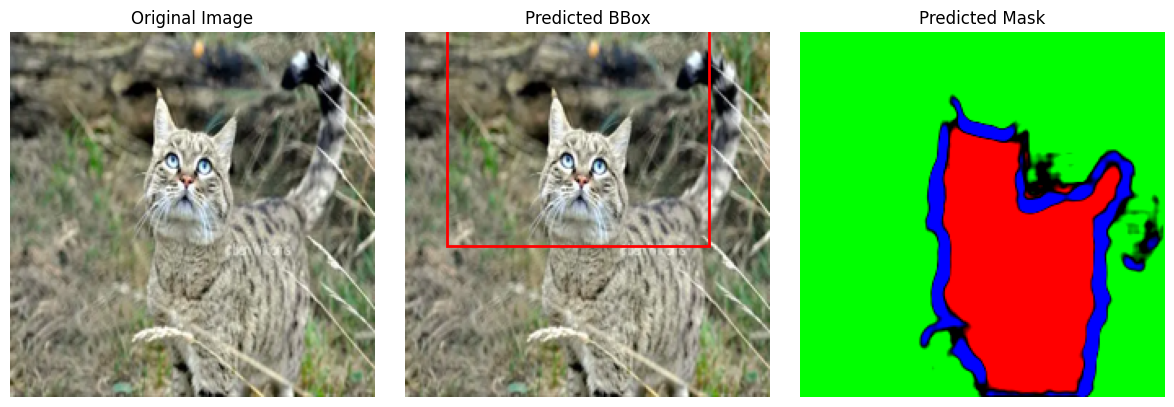

In [171]:
wandb.init(project="Multitask-Pet-Detection")

img = Image.open("img3.jpg").convert("RGB")
img = img.resize((224, 224))

img_tensor = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 255.0

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_tensor = (img_tensor - mean) / std


img_tensor = img_tensor.unsqueeze(0)

with torch.no_grad():
    predictions = multitask_model(img_tensor)

# Get outputs
class_pred = torch.argmax(torch.softmax(predictions["classification"], dim=1), dim=1)
bbox_pred  = predictions["localization"][0].detach().cpu().numpy()
mask_pred  = predictions["segmentation"][0].detach().cpu()

# De-normalize image
img = img_tensor[0].cpu()
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img = img * std + mean

# Plot
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# --- 1. Original Image ---
ax[0].imshow(img.permute(1,2,0).numpy())
ax[0].set_title("Original Image")
ax[0].axis("off")

# --- 2. Image + BBox ---
ax[1].imshow(img.permute(1,2,0).numpy())
ax[1].set_title("Predicted BBox")
ax[1].axis("off")

_, H, W = img.shape
xc, yc, w, h = bbox_pred

x = (xc - w/2) * W
y = (yc - h/2) * H
w = w * W
h = h * H

rect = patches.Rectangle((x, y), w, h,
                         linewidth=2, edgecolor='r', facecolor='none')
ax[1].add_patch(rect)

ax[2].imshow(mask_pred.squeeze().permute(1, 2, 0).numpy(), cmap="gray")
ax[2].set_title("Predicted Mask")
ax[2].axis("off")

plt.tight_layout()

wandb.log({
    "prediction_panel": wandb.Image(fig)
})

wandb.finish()